DATASET LOADED SUCCESSFULLY

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

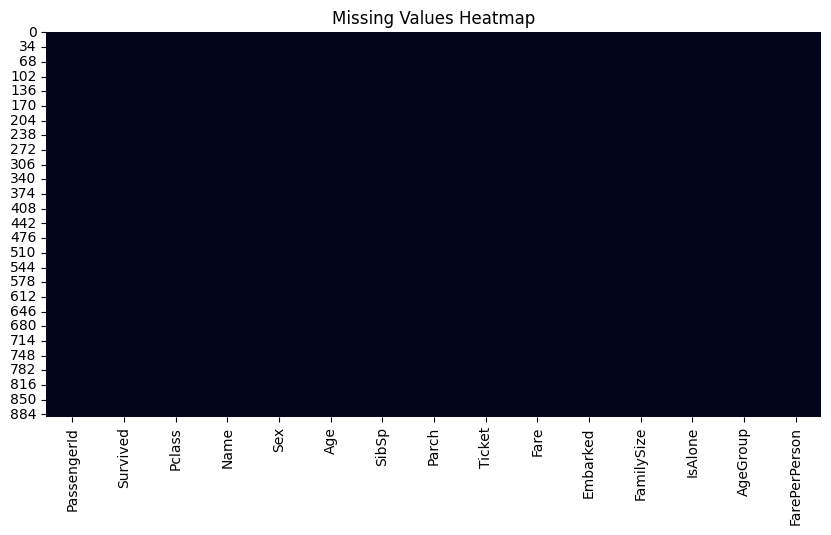

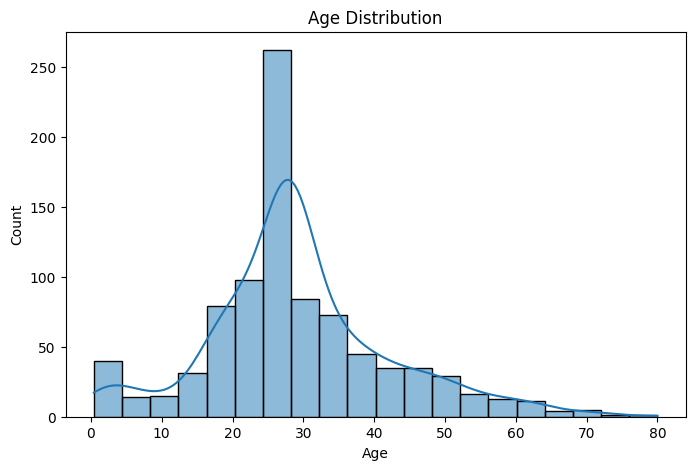

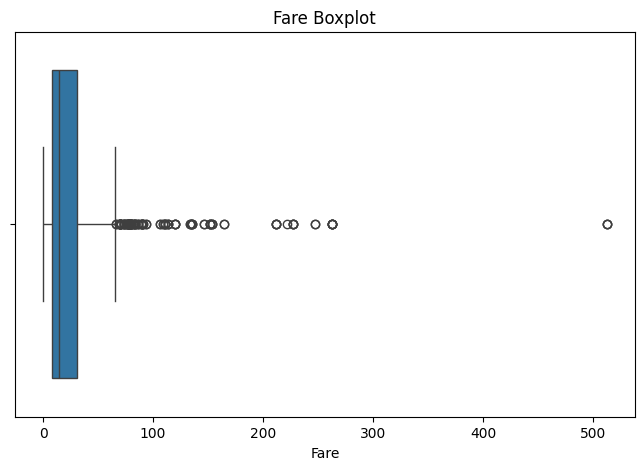

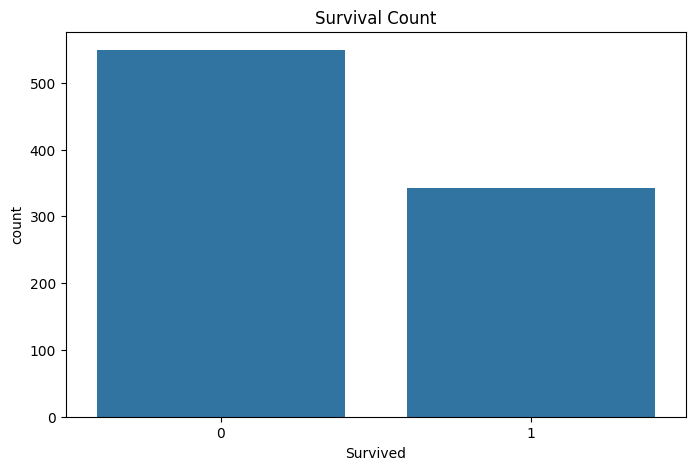

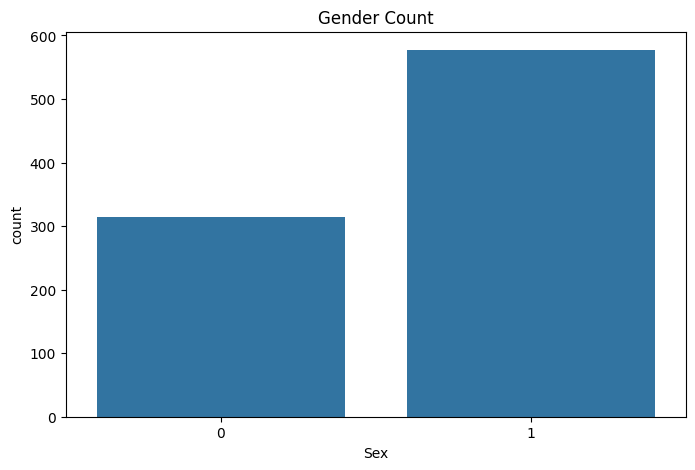

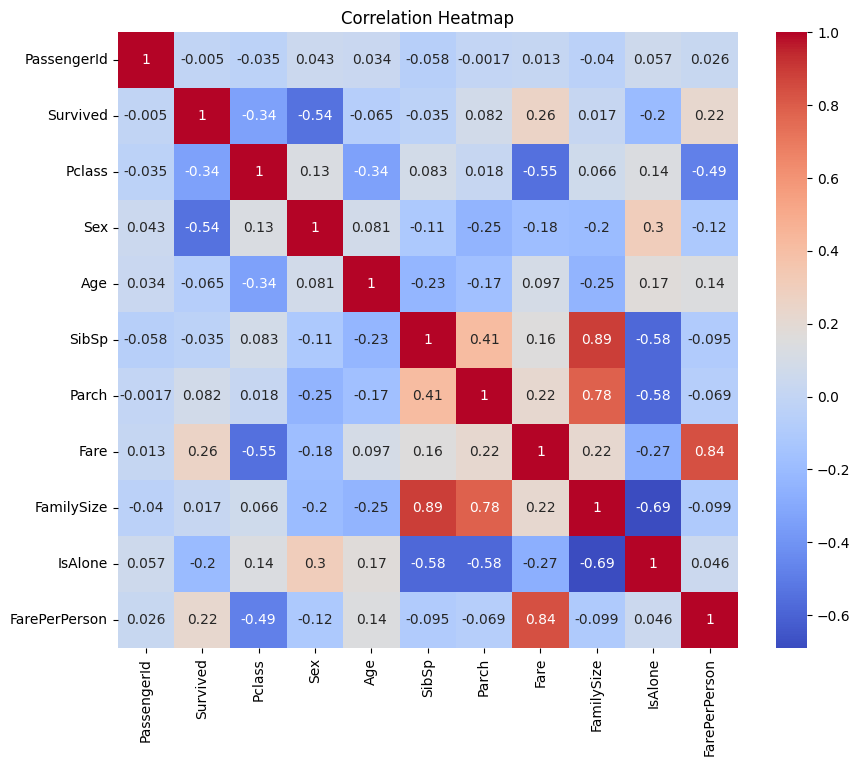


PROJECT COMPLETED SUCCESSFULLY

Final Dataset Shape: (891, 15)

Final Dataset Preview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare Embarked  FamilySize  IsAlone AgeGroup  \
0         A/5 21171   7.2500        S           2        0    Young   
1          PC 17599  71.2833        C           2        0    Adul

In [1]:
# ==========================================
# DecodeLabs Project 1
# Advanced EDA & Feature Engineering
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("titanic.csv")

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

# ==========================================
# Basic EDA
# ==========================================

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# Missing Value Comparison
# ==========================================

print("\n==============================")
print("MISSING VALUE COMPARISON")
print("==============================")

mean_df = df.copy()
median_df = df.copy()
knn_df = df.copy()

# Mean
mean_df["Age"] = SimpleImputer(strategy="mean").fit_transform(mean_df[["Age"]])

# Median
median_df["Age"] = SimpleImputer(strategy="median").fit_transform(median_df[["Age"]])

# KNN
knn = KNNImputer(n_neighbors=5)
knn_df[["Age","Fare"]] = knn.fit_transform(knn_df[["Age","Fare"]])

print("Mean Age :", mean_df["Age"].mean())
print("Median Age :", median_df["Age"].median())
print("Remaining Missing (KNN):", knn_df["Age"].isnull().sum())

# ==========================================
# Final Cleaning
# ==========================================

df["Age"] = SimpleImputer(strategy="median").fit_transform(df[["Age"]])

df["Embarked"] = SimpleImputer(strategy="most_frequent").fit_transform(df[["Embarked"]]).ravel()

df.drop(columns=["Cabin"], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ==========================================
# Outlier Detection (IQR)
# ==========================================

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

print("\nOriginal Shape :", df.shape)
print("After IQR :", iqr_df.shape)

# ==========================================
# Outlier Detection (Z-Score)
# ==========================================

z = np.abs(zscore(df["Fare"]))

zscore_df = df[z < 3]

print("After Z-Score :", zscore_df.shape)

# ==========================================
# Feature Engineering
# ==========================================

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,19,35,60,100],
    labels=["Child","Teen","Young","Adult","Senior"]
)

df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

df["Sex"] = df["Sex"].map({"male":1,"female":0})

print("\nNew Features Created Successfully")

print(df[["FamilySize","IsAlone","AgeGroup","FarePerPerson"]].head())

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="Sex", data=df)
plt.title("Gender Count")
plt.show()

plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# Save Clean Dataset
# ==========================================

df.to_csv("clean_titanic.csv", index=False)

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("\nFinal Dataset Shape:", df.shape)

print("\nFinal Dataset Preview:")
print(df.head())

print("\nClean dataset saved as 'clean_titanic.csv'")